## <center>CITS5508 Assignment 2</center>

Author: Seng Qi Ming (25303739)

 - [Ensemble Learning for Heart Disease Prediction](#part-1-ensemble-learning-for-heart-disease-prediction)
 - [Clustering of Faces](#part-2-clustering-of-faces)

In this assignment we will first use ensemble learning for heart disease prediction, for the next part we will explore on technique for clustering of faces.

### Importing necessary libraries

In [1]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import pandas as pd
import numpy as np
import graphviz

from sklearn import tree
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, VotingClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, silhouette_score, silhouette_samples
from sklearn.cluster import KMeans
from sklearn.preprocessing import OneHotEncoder

## Part 1: Ensemble Learning for Heart Disease Prediction

In this task, we will compare a range of ensemble methods for predicting the presence of heart disease
in patients

### 1.1: Load the dataset & Inspect the data
We will first load the dataset using the `processed.cleveland.data`

| Variable Name | Role | Type | Description | Missing Values |
|---------------|-----|------|-------------|----------------|
| age           | Feature|Integer| | No|
| sex           | Feature|Categorical| | No |
| cp            | Feature|Categorical| | No |
| trestbps      | Feature| Integer| resting blood pressure (on admission to the hospital)| No |
| chol      | Feature| Integer| serum cholestoral | No |
| fbs      | Feature| Categorical | fasting blood sugar > 120 mg/dl| No |
| restecg      | Feature| Categorical | | No |
| thalach      | Feature| Integer| maximum heart rate achieved | No |
| exang      | Feature| Categorical | exercise induced angina| No |
| oldpeak      | Feature| Integer| ST depression induced by exercise relative to rest | No |
| slope      | Feature| Categorical| | No |
| ca      | Feature| Integer| number of major vessels (0-3) colored by flourosopy| Yes |
| thal      | Feature| Categorical| | Yes |
| num      | Target| Integer| diagnosis of heart disease| No |


In [2]:
column_names = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']

data = pd.read_csv('processed.cleveland.data', names=column_names, na_values='?')

In [3]:
data.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  num       303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


In [5]:
n_examples = data.shape[0]
n_features = data.shape[1]

numeric_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']
categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']

print(f'Number of examples: {n_examples}')
print(f'Number of features (including target): {n_features}')
print(f'Numeric features: {numeric_features}')
print(f'Categorical features: {categorical_features}')

data['num_binary'] = (data['num'] > 0).astype(int)
print('Target distribution (original):')
print(data['num'].value_counts().sort_index())
print('Target distribution (binary):')
print(data['num_binary'].value_counts().sort_index())

Number of examples: 303
Number of features (including target): 14
Numeric features: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']
Categorical features: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
Target distribution (original):
num
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64
Target distribution (binary):
num_binary
0    164
1    139
Name: count, dtype: int64


### Observation
- There are 303 examples (which mean 303 patients).
- There are 13 features (excluding the target). 
    - Numeric: `age`, `trestbps`, `chol`, `thalach`, `oldpeak`, `ca`.
    - Categorical: `sex`, `cp`, `fbs`, `restecg`, `exang`, `slope`, `thal`.

#### 1.2 Splitting of dataset
Split the dataset into a training and testing set. Use 80% of the data for training, and 20% for
testing. Make sure to stratify your split. 
For row with missing values, we will drop the row

In [6]:
# We will drop the rows with missing values 
data = data.dropna()

In [7]:
# Split to X and Y first 
X = data.drop(columns=['num', 'num_binary'])
y = data['num_binary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print(f"Train samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")

Train samples: 237, Test samples: 60


#### 1.3 Using a single Decision Tree classifier on our dataset

Fit a single Decision Tree classifier using scikit-learn as a baseline and evaluate its performance on the test set.

In [8]:
dt_clf = DecisionTreeClassifier(random_state=42)
dt_clf.fit(X_train, y_train)

y_pred = dt_clf.predict(X_test)

print(f'\nClasification Report \n {classification_report(y_true=y_test, y_pred=y_pred)}')


Clasification Report 
               precision    recall  f1-score   support

           0       0.71      0.75      0.73        32
           1       0.69      0.64      0.67        28

    accuracy                           0.70        60
   macro avg       0.70      0.70      0.70        60
weighted avg       0.70      0.70      0.70        60




Clasification Report 
               precision    recall  f1-score   support

           0       0.71      0.75      0.73        32
           1       0.69      0.64      0.67        28

    accuracy                           0.70        60
   macro avg       0.70      0.70      0.70        60
weighted avg       0.70      0.70      0.70        60



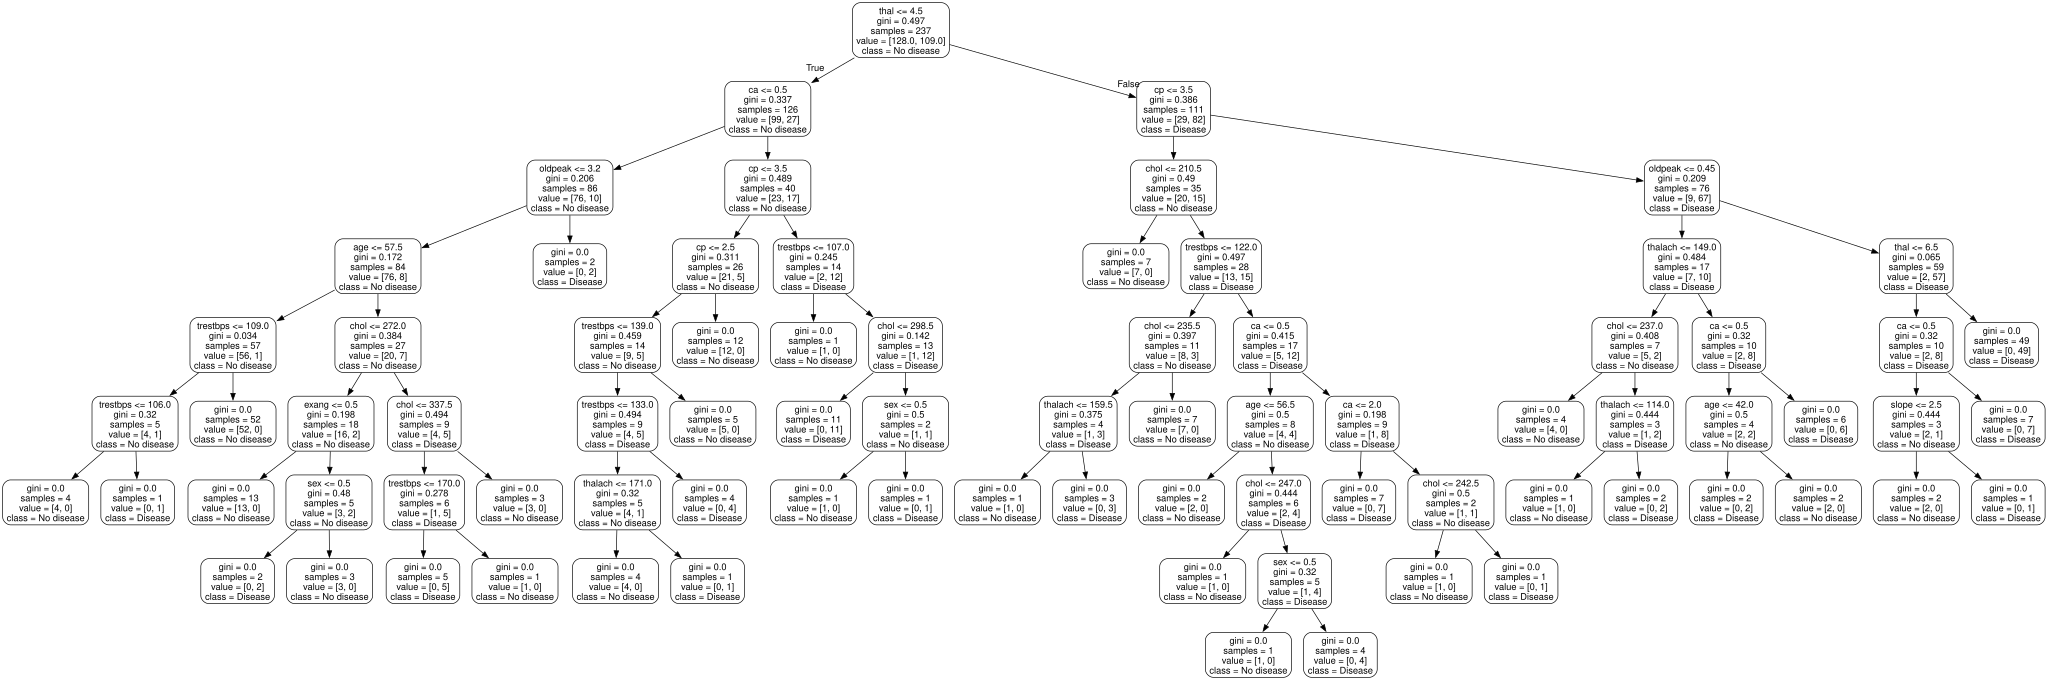

In [9]:
dt_clf = DecisionTreeClassifier(random_state=42)
dt_clf.fit(X_train, y_train)

y_pred = dt_clf.predict(X_test)

print(f'\nClasification Report \n {classification_report(y_true=y_test, y_pred=y_pred)}')

tree_viz = graphviz.Source(
    tree.export_graphviz(
        dt_clf,
        feature_names=X_test.columns,
        class_names=["No disease", "Disease"],
        filled=False,
        rounded=True,
    )
)
tree_viz

#### 1.4 Fitting of Random Forest Classifier and AdaBoost Classifier

In [10]:
rf_clf = RandomForestClassifier(n_estimators=500, random_state=42)
rf_clf.fit(X_train, y_train)

ada_clf = AdaBoostClassifier(n_estimators=500, random_state=42)
ada_clf.fit(X_train, y_train)

AdaBoostClassifier(n_estimators=500, random_state=42)

#### 1.5 Combining both Random Forest  classifier and Adaboost Classifier using Voting Classifier

In [11]:
voting_clf = VotingClassifier(estimators=[('rf_clf', rf_clf), ('ada_clf', ada_clf)], voting='soft')

voting_clf.fit(X_train, y_train)

VotingClassifier(estimators=[('rf_clf',
                              RandomForestClassifier(n_estimators=500,
                                                     random_state=42)),
                             ('ada_clf',
                              AdaBoostClassifier(n_estimators=500,
                                                 random_state=42))],
                 voting='soft')

#### 1.6 Comparing model performance

In [12]:
models = {'Decision Tree': dt_clf, 'Random Forest': rf_clf, 'AdaBoost': ada_clf, 'Voting Classifier':voting_clf}

reports = {}
for name, model in models.items():
    report = classification_report(y_test, model.predict(X_test), output_dict=True)
    reports[name] = pd.DataFrame(report).T  # rows: class/avg, cols: precision/recall/f1/support

side_by_side = pd.concat(reports, axis=1)
display(side_by_side)


Decision Tree                             Random Forest  \
                 precision    recall  f1-score support     precision   
0                 0.705882  0.750000  0.727273    32.0      0.852941   
1                 0.692308  0.642857  0.666667    28.0      0.884615   
accuracy          0.700000  0.700000  0.700000     0.7      0.866667   
macro avg         0.699095  0.696429  0.696970    60.0      0.868778   
weighted avg      0.699548  0.700000  0.698990    60.0      0.867722   

                                             AdaBoost                      \
                recall  f1-score    support precision    recall  f1-score   
0             0.906250  0.878788  32.000000  0.870968  0.843750  0.857143   
1             0.821429  0.851852  28.000000  0.827586  0.857143  0.842105   
accuracy      0.866667  0.866667   0.866667  0.850000  0.850000  0.850000   
macro avg     0.863839  0.865320  60.000000  0.849277  0.850446  0.849624   
weighted avg  0.866667  0.866218  60.000000  0.850723  0.850000  0.850125   

                     Voting Classifier                                 
             support         precision    recall  f1-score    support  
0              32.00          0.852941  0.906250  0.878788  32.000000  
1              28.00          0.884615  0.821429  0.851852  28.000000  
accuracy        0.85          0.866667  0.866667  0.866667   0.866667  
macro avg      60.00          0.868778  0.863839  0.865320  60.000000  
weighted avg   60.00          0.867722  0.866667  0.866218  60.000000

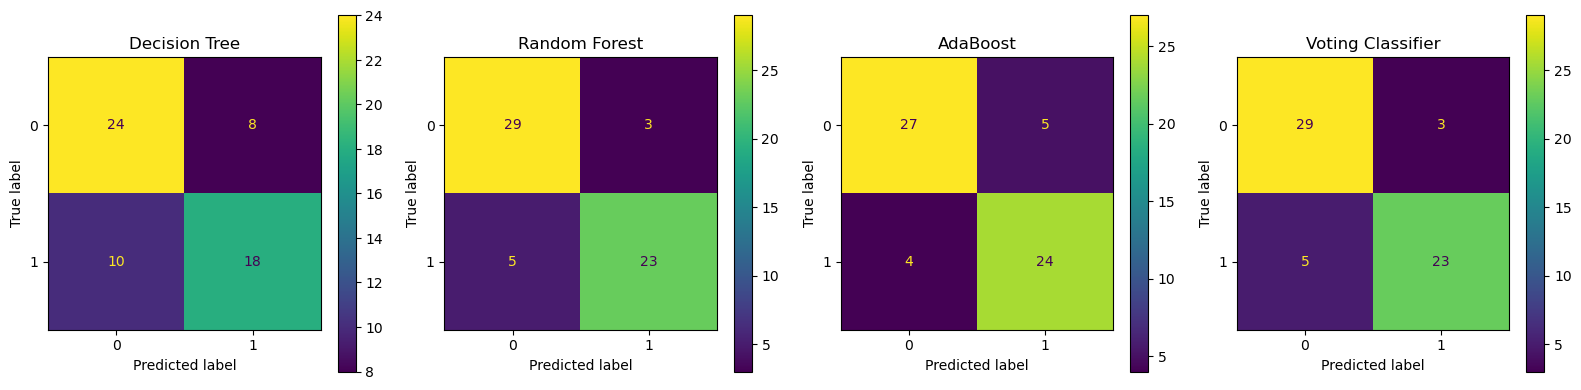

In [13]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (name, model) in zip(axes, models.items()):
    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, ax=ax)
    ax.set_title(name)
plt.tight_layout()
plt.show()

#### 1.7 Plot the feature importances of your Random Forest 

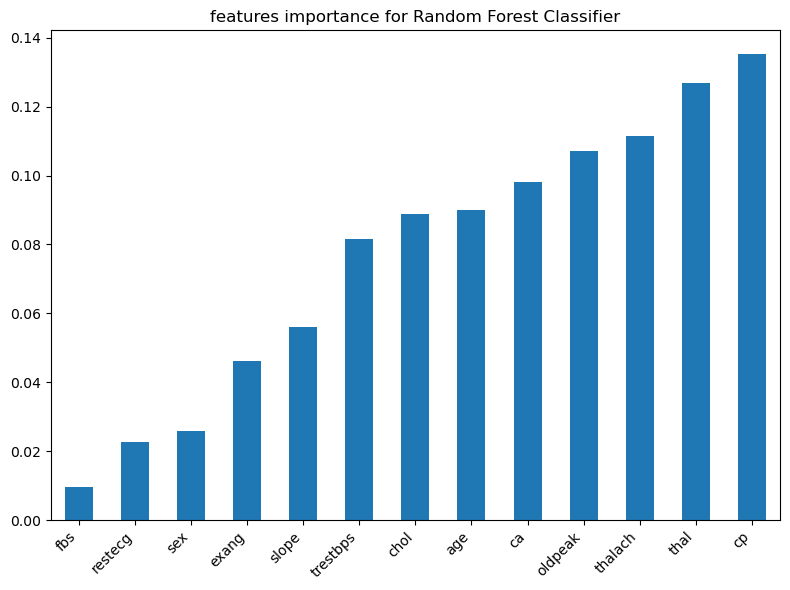

In [14]:
feat_impt = pd.Series(rf_clf.feature_importances_, index=X.columns).sort_values(ascending=True)

feat_impt.plot(kind='bar', figsize=(8,6), title='features importance for Random Forest Classifier')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Part 2: Clustering of Faces



### 2.1 Load the dataset & Inspect the data

In [15]:
from sklearn.datasets import fetch_olivetti_faces
data, targets = fetch_olivetti_faces(return_X_y=True)

In [16]:
print(f"Number of examples: {data.shape[0]}")
print(f"Number of features: {data.shape[1]} (64x64)")
print(f"Number of classes: {len(np.unique(targets))}")
print(f"Images per class: {len(targets) // len(np.unique(targets))}")
print(f"Pixel value range: [{data.min():.1f}, {data.max():.1f}]")


Number of examples: 400
Number of features: 4096 (64x64)
Number of classes: 40
Images per class: 10
Pixel value range: [0.0, 1.0]


We got 400 examples, 4096 features
each example contains a picture of a face where each feature contain different style of a face.

### 2.2 Sample a random example from each class and display the images in a grid.

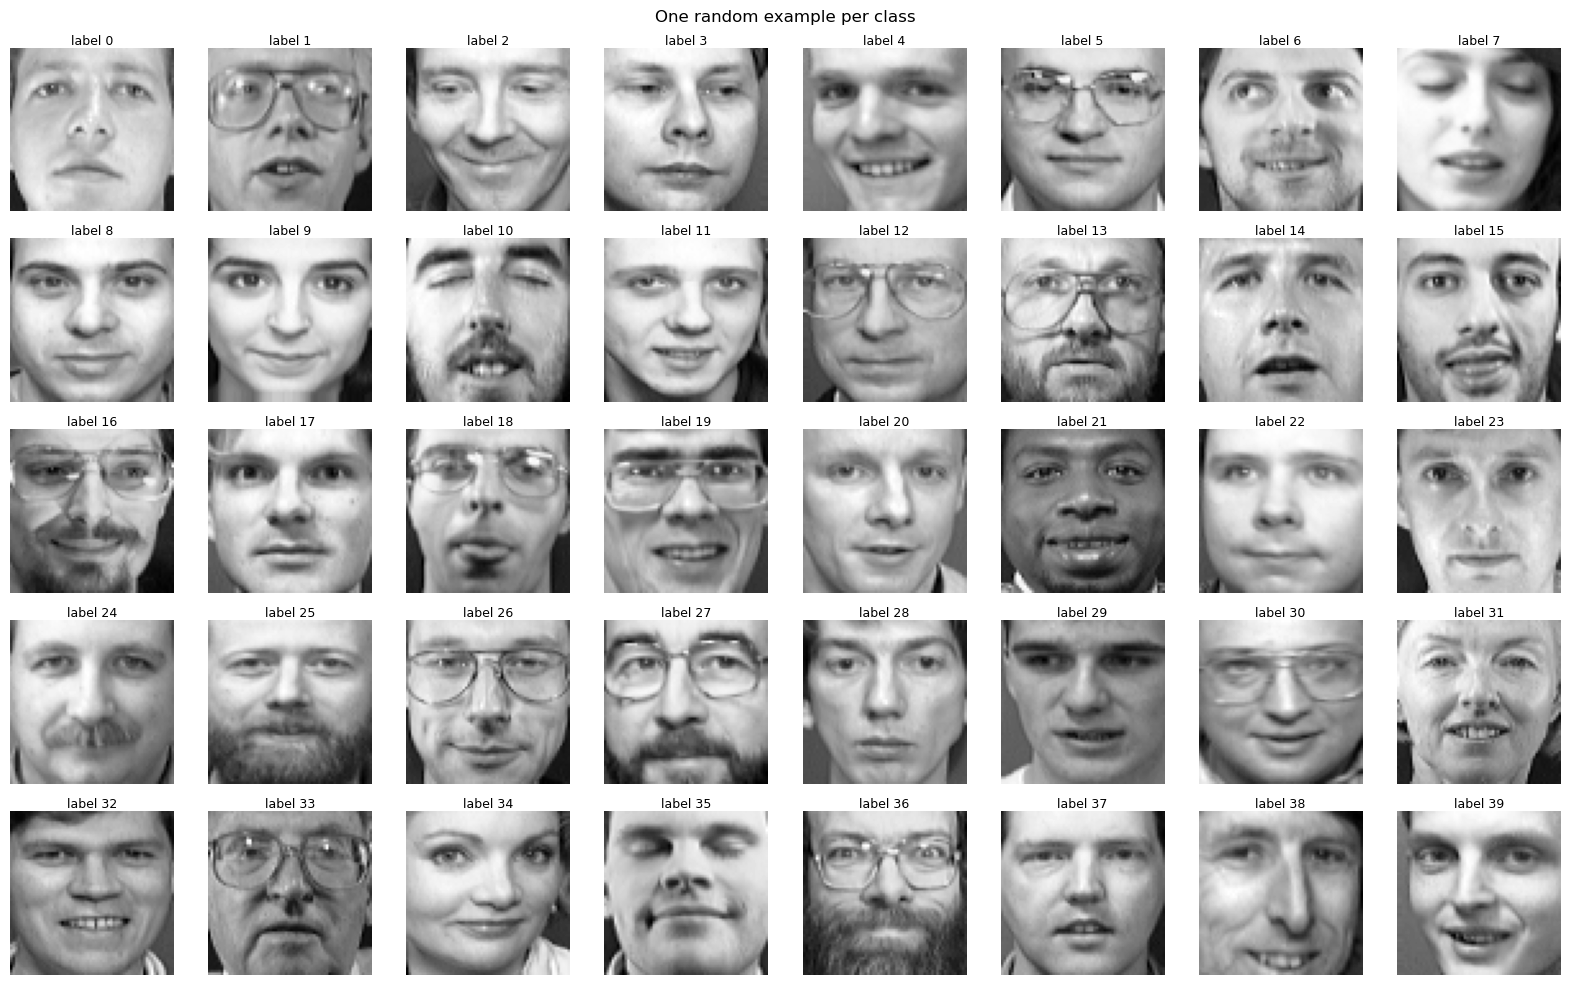

In [17]:
np.random.seed(42)

classes = np.unique(targets)
n_classes = len(classes)
n_cols = 8
n_rows = int(np.ceil(n_classes / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 10))
axes = axes.flatten()

for i, cls in enumerate(classes):
    idx = np.random.choice(np.where(targets == cls)[0])
    img = data[idx].reshape(64, 64)  # 64 * 64 = 4096
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f'label {cls}', pad=2, fontsize=9)
    axes[i].axis('off')

for j in range(n_classes, len(axes)):
    axes[j].axis('off')

plt.suptitle('One random example per class')
plt.tight_layout()
plt.show()